---
title: Outlier Detection and Removal
description: Discover methods to identify and handle anomalous data points using the Interquartile Range (IQR) method, comparing trimming and capping strategies to prepare cleaner datasets for machine learning.
author: Md Muztahid Hassan
date: '2026-05-31 20:19:00'
toc: true
execute:
  warning: false
  echo: true
---

## Interquartile Range (IQR) Technique

The Interquartile Range (IQR) is a measure of statistical dispersion and is a widely used method for detecting outliers in a dataset. It represents the range between the first quartile (25th percentile, $Q_1$) and the third quartile (75th percentile, $Q_3$):

$$\text{IQR} = Q_3 - Q_1$$

#### Identifying Outliers:
Data points are considered outliers if they fall outside the bounds:
* **Lower Bound:** $Q_1 - 1.5 \times \text{IQR}$
* **Upper Bound:** $Q_3 + 1.5 \times \text{IQR}$

Here is an image that shows the IQR method.

![IQR_graph](images/IQR_graph.png)

If there are any data points that fall outside these bounds, they are typically considered outliers. We can handle outliers in two ways:
1. Trimming
2. Capping

### Trimming vs. Capping (Winsorization)

When handling outliers, two common approaches are **Trimming** and **Capping**:

#### 1. Trimming (Truncation)
Trimming involves completely removing the outlier data points from the dataset.

* **Benefits:**
  * Simple and straightforward to implement.
  * Fully eliminates the influence of extreme values on models.
* **Limitations/Problems of Trimming:**
  * **Loss of Information:** If a row contains an outlier in one feature but valuable, normal information in all other features, trimming discards all of that valid information.
  * **Reduced Data Size:** In smaller datasets, removing rows can significantly reduce the amount of training data, potentially leading to overfitting or loss of statistical power.
  * **Bias Induction:** If outliers are not randomly distributed, deleting them can introduce systematic bias into the dataset.
* **When to use:** Use when you have a large dataset and the outliers represent genuine errors or data corruption that does not carry useful information.

#### 2. Capping (Winsorization)
Capping limits the extreme values by replacing outliers with the nearest non-outlier values (the threshold boundaries, e.g., the Lower and Upper bounds). That means, if a data point is below the lower bound, it is set to the lower bound value; if it is above the upper bound, it is set to the upper bound value.

* **Benefits:**
  * Preserves the sample size (no data points are deleted).
  * Prevents loss of potentially valuable information contained in other features of the outlier rows.
* **When to use:** Use capping when your dataset is relatively small. If we have a large dataset, we should prefer trimming over capping. 


Now we will see them in code.

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Now we will load the dataset. You can download the dataset from <a href="placement.csv" download>here</a>.

In [31]:
df = pd.read_csv('placement.csv')
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


Here `placed` is a target column. At first, we will see the distribution of the `cgpa` and `placement_exam_marks` columns.

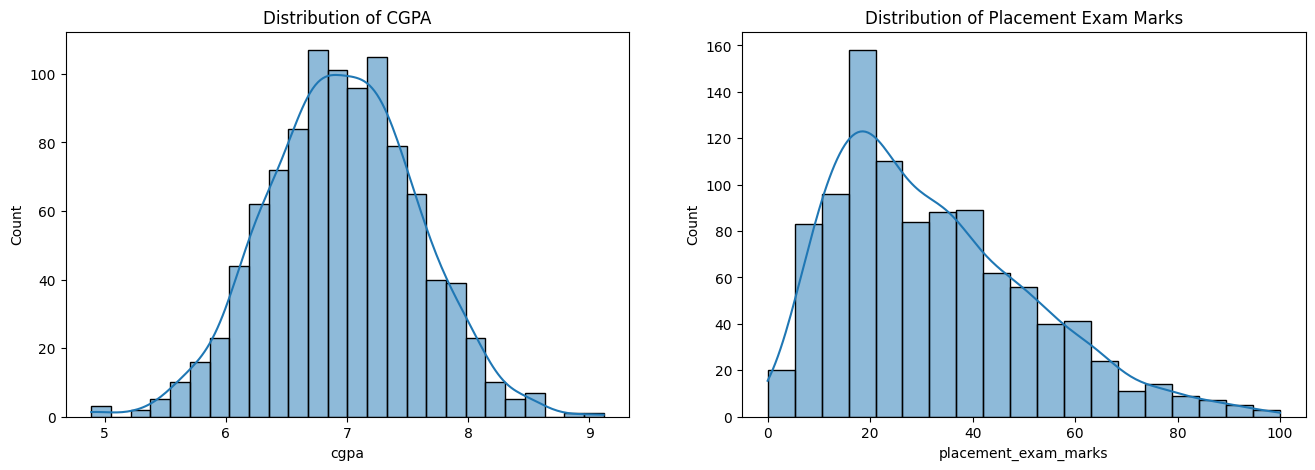

In [32]:
plt.figure(figsize=(16, 5))
plt.subplot(121)
sns.histplot(df['cgpa'], kde=True)
plt.title('Distribution of CGPA')

plt.subplot(122)
sns.histplot(df['placement_exam_marks'], kde=True)
plt.title('Distribution of Placement Exam Marks')
plt.show()

Let's see the statistical summary of the dataset.

In [33]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

**Insights:**
Look at the max value of the `placement_exam_marks` column. It is 100, which is too much higher than the 75% value (which is 44). This indicates that there are some outliers in the `placement_exam_marks` column. Let's see them in a boxplot.

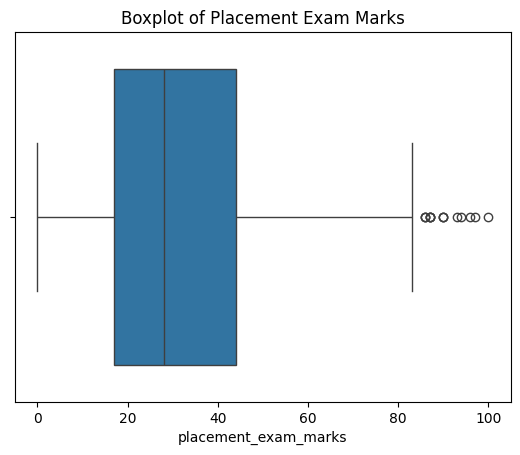

In [34]:
sns.boxplot(x=df['placement_exam_marks'])
plt.title('Boxplot of Placement Exam Marks')
plt.show()

We can see the outliers in the boxplot. Now we will handle them using the IQR method. 

In [35]:
Q1, Q3 = np.percentile(df['placement_exam_marks'], [25, 75])
Q1, Q3

(np.float64(17.0), np.float64(44.0))

In [36]:
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
lower_bound, upper_bound

(np.float64(-23.5), np.float64(84.5))

Let's find the outliers. We will create a function to find the outliers using the IQR method.

In [37]:
def detect_outliers_iqr(data, column):
    """
    Generalized function to calculate IQR, lower & upper bounds,
    and find outliers in a specified column of a DataFrame.
    """
    # Calculate Q1 (25th percentile) and Q3 (75th percentile)
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    
    # Calculate Interquartile Range (IQR)
    iqr = q3 - q1
    
    # Define bounds
    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr
    
    # Identify outliers
    outliers = data[(data[column] < lower_limit) | (data[column] > upper_limit)]
    
    print(f"--- Outlier Detection Analysis for '{column}' ---")
    print(f"Q1 (25th percentile): {q1:.4f}")
    print(f"Q3 (75th percentile): {q3:.4f}")
    print(f"IQR: {iqr:.4f}")
    print(f"Lower Limit (Bound): {lower_limit:.4f}")
    print(f"Upper Limit (Bound): {upper_limit:.4f}")
    print(f"Number of Outliers: {len(outliers)}\n")
    
    return lower_limit, upper_limit, outliers

These are the outliers. Now we will either trim or cap them. 

## Trimming

Here is a generic function to trim the outliers.

In [38]:
def generate_clean_dataset(data, column, lower_limit, upper_limit):
    """
    Generalized function to return a trimmed (outlier-free) dataset
    by removing values outside the specified lower and upper bounds.
    """
    clean_data = data[(data[column] >= lower_limit) & (data[column] <= upper_limit)]
    print(f"--- Dataset Trimming Report ---")
    print(f"Original shape: {data.shape}")
    print(f"Cleaned shape: {clean_data.shape}")
    print(f"Removed {len(data) - len(clean_data)} outliers.")
    return clean_data

In [39]:
lower_bound, upper_bound, outliers_df = detect_outliers_iqr(df, 'placement_exam_marks')
outliers_df

--- Outlier Detection Analysis for 'placement_exam_marks' ---
Q1 (25th percentile): 17.0000
Q3 (75th percentile): 44.0000
IQR: 27.0000
Lower Limit (Bound): -23.5000
Upper Limit (Bound): 84.5000
Number of Outliers: 15



,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [40]:
df_clean = generate_clean_dataset(df, 'placement_exam_marks', lower_bound, upper_bound)

--- Dataset Trimming Report ---
Original shape: (1000, 3)
Cleaned shape: (985, 3)
Removed 15 outliers.


Now let's see them in graphs.

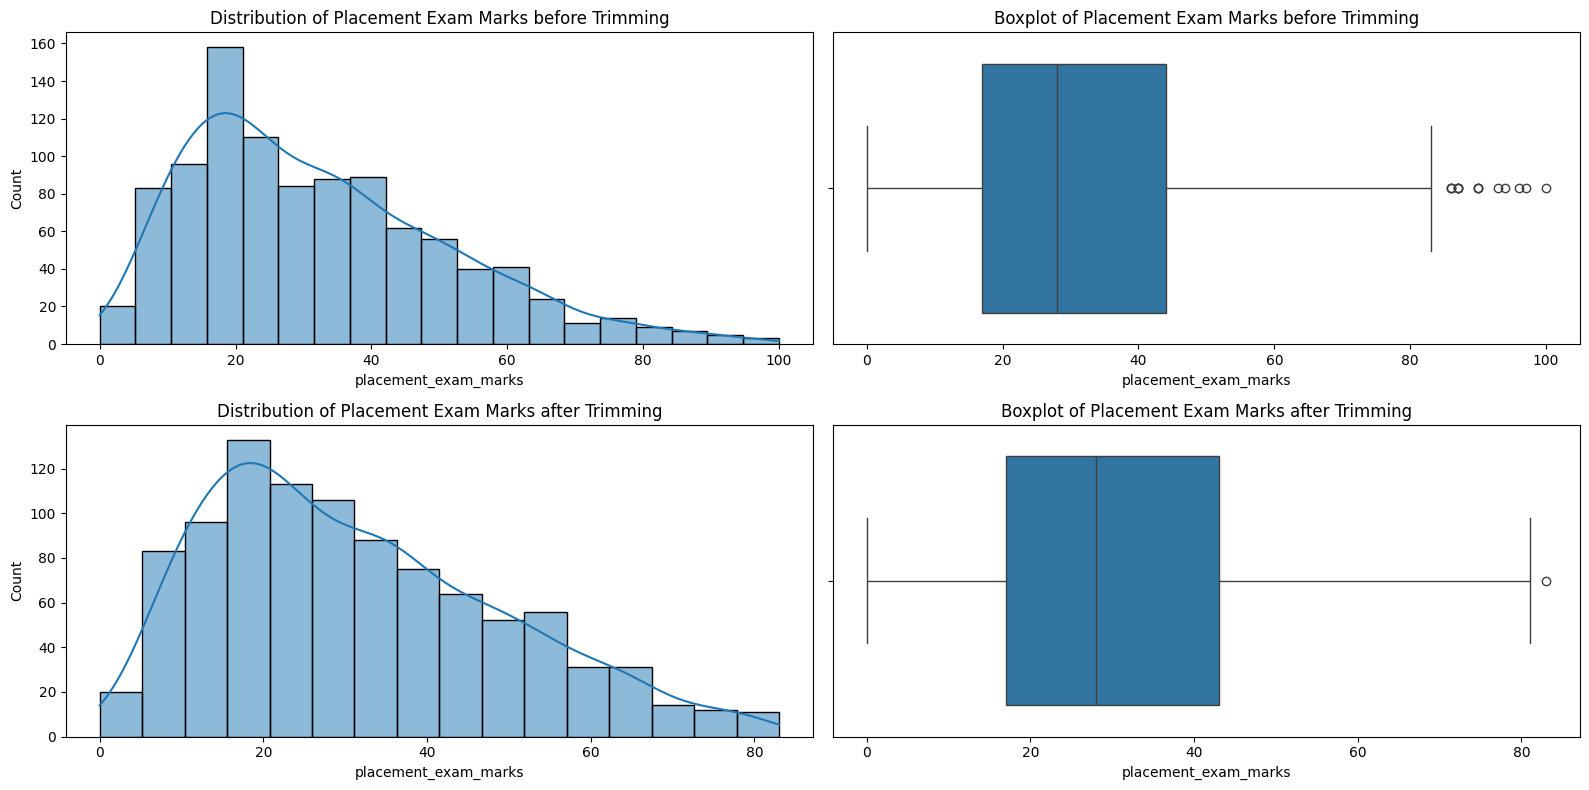

In [41]:
plt.figure(figsize=(16, 8))
plt.subplot(221)
sns.histplot(df['placement_exam_marks'], kde=True)
plt.title('Distribution of Placement Exam Marks before Trimming')

plt.subplot(222)
sns.boxplot(x=df['placement_exam_marks'])
plt.title('Boxplot of Placement Exam Marks before Trimming')

plt.subplot(223)
sns.histplot(df_clean['placement_exam_marks'], kde=True)
plt.title('Distribution of Placement Exam Marks after Trimming')

plt.subplot(224)
sns.boxplot(x=df_clean['placement_exam_marks'])
plt.title('Boxplot of Placement Exam Marks after Trimming')

plt.tight_layout()
plt.show()

The kde plot is still right-skewed. If we want to make it normally distributed, we need log transformation. But this not today's topic. 

## Capping (Winsorization)

In [42]:
def cap_outliers_iqr(data, column, lower_limit, upper_limit):
    """
    Generalized function to cap outliers in a specified column of a DataFrame.
    Replaces values below lower_limit with lower_limit and values above upper_limit with upper_limit.
    """
    capped_data = data.copy()
    
    # Cap the values using clip
    capped_data[column] = capped_data[column].clip(lower=lower_limit, upper=upper_limit)
    
    print(f"--- Dataset Capping (Winsorization) Report for '{column}' ---")
    print(f"Original Min: {data[column].min():.4f} | Capped Min: {capped_data[column].min():.4f}")
    print(f"Original Max: {data[column].max():.4f} | Capped Max: {capped_data[column].max():.4f}")
    print(f"Number of values capped: {len(data[ (data[column] < lower_limit) | (data[column] > upper_limit) ])}")
    
    return capped_data

In [43]:
df_capped = cap_outliers_iqr(df, 'placement_exam_marks', lower_bound, upper_bound)

--- Dataset Capping (Winsorization) Report for 'placement_exam_marks' ---
Original Min: 0.0000 | Capped Min: 0.0000
Original Max: 100.0000 | Capped Max: 84.5000
Number of values capped: 15


In [44]:
df.shape, df_capped.shape

((1000, 3), (1000, 3))

Look at the shapes of the original and capped datasets. It is the same. Now let's see them in graphs.

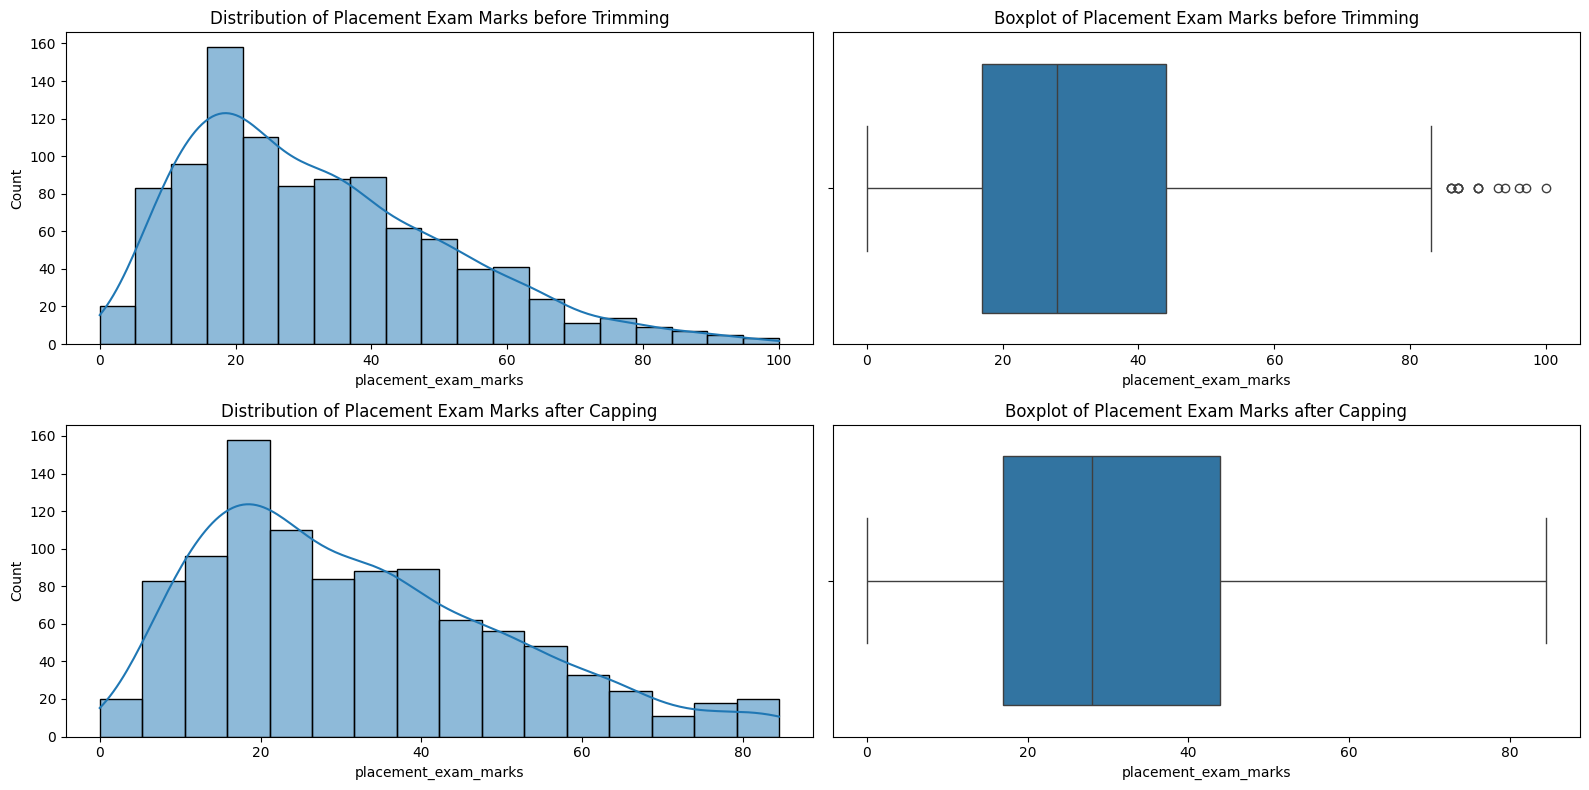

In [45]:
plt.figure(figsize=(16, 8))
plt.subplot(221)
sns.histplot(df['placement_exam_marks'], kde=True)
plt.title('Distribution of Placement Exam Marks before Trimming')

plt.subplot(222)
sns.boxplot(x=df['placement_exam_marks'])
plt.title('Boxplot of Placement Exam Marks before Trimming')

plt.subplot(223)
sns.histplot(df_capped['placement_exam_marks'], kde=True)
plt.title('Distribution of Placement Exam Marks after Capping')

plt.subplot(224)
sns.boxplot(x=df_capped['placement_exam_marks'])
plt.title('Boxplot of Placement Exam Marks after Capping')

plt.tight_layout()
plt.show()